# Testing `patch_sv_stream`

Scratch notebook: load the first 10 MNIST images, build their Method 1 (patch singular-value) stream representation using `signature_distance/streams.py`, and inspect the result. This notebook only imports from the package — no package code is modified here.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from streams import *

## Load the first 10 MNIST images

Test set, in dataset order (no shuffling) — reuses the MNIST copy already cached for `mnist_lipschitz`.

In [2]:
DATA_ROOT = Path.cwd().parent / "mnist_lipschitz" / "data"

dataset = datasets.MNIST(root=str(DATA_ROOT), train=False, download=True, transform=transforms.ToTensor())

images = torch.stack([dataset[i][0].squeeze(0) for i in range(10)]).to(torch.float32)
labels = torch.tensor([dataset[i][1] for i in range(10)], dtype=torch.int64)

print("images:", images.shape, images.dtype, "range:", images.min().item(), images.max().item())
print("labels:", labels.tolist())

images: torch.Size([10, 28, 28]) torch.float32 range: 0.0 1.0
labels: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]


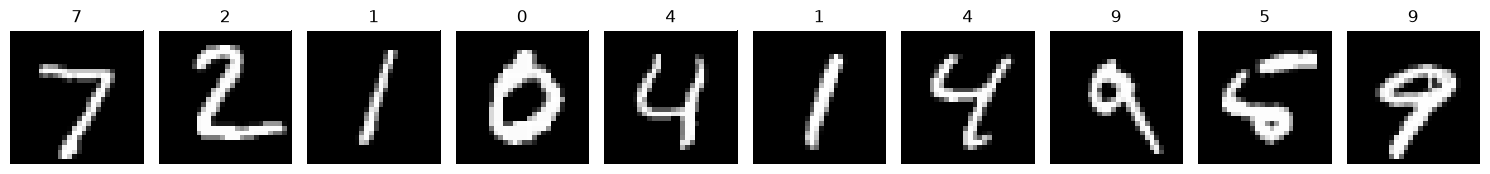

In [3]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i], cmap="gray")
    ax.set_title(str(labels[i].item()))
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
pixel_order = make_pixel_order()
print(len(pixel_order))

64


In [5]:
signature = patch_sv_stream(images,pixel_order)
print(signature)

patch_sv_stream: images.shape=torch.Size([10, 28, 28]), pixel_order.shape=torch.Size([64, 2]), mode=top1
The shape of the jax array is: (10, 64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
basis size: 5
one row shape: (64, 2)
Computed 10 signatures. First signature shape: (15,)


TypeError: expected Tensor as element 0 in argument 0, but got numpy.ndarray